In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# 1. Load and Merge Data
shootings_df = pd.read_csv('/content/clean_shootings.csv')
agencies_df = pd.read_csv('/content/clean_agencies.csv')
df = pd.merge(shootings_df, agencies_df, left_on='agency_id', right_on='id', how='left', suffixes=('_shoot', '_agency'))

# 2. Data Cleaning & Feature Engineering
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')
df['age'] = df['age'].fillna(df['age'].median()) # Fill missing ages with median

print("Data loaded and preprocessed. Total records:", len(df))

Data loaded and preprocessed. Total records: 13289


Cell 2: Correlation and Exploratory Visualization
This checks the correlation between numerical and boolean features (like Age, Mental Illness, Body Camera, and Total Agency Shootings).

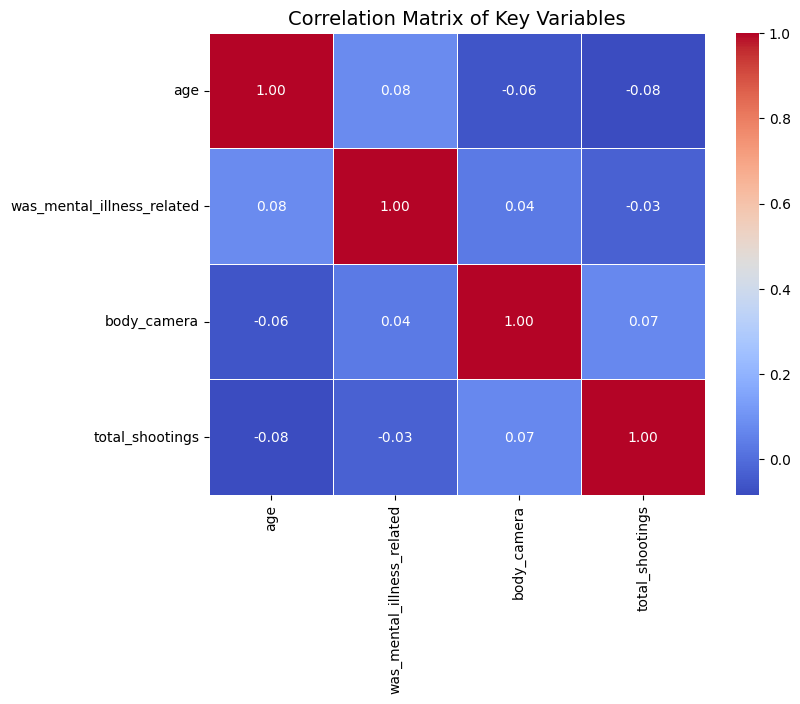

In [ ]:
plt.figure(figsize=(8, 6))
# Select numerical/boolean columns for correlation
corr_cols = ['age', 'was_mental_illness_related', 'body_camera', 'total_shootings']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Variables", fontsize=14)
plt.show()

Cell 3: Hypothesis Testing
Question: Is the average age of victims significantly different when mental illness is involved? (Independent T-Test)
Question: Is there a relationship between threat type and whether a body camera was worn? (Chi-Square Test)

In [ ]:
print("--- HYPOTHESIS TESTING ---")

# 1. T-Test: Age vs. Mental Illness
age_mental = df[df['was_mental_illness_related'] == True]['age']
age_no_mental = df[df['was_mental_illness_related'] == False]['age']

t_stat, p_val_t = ttest_ind(age_mental, age_no_mental, equal_var=False)
print(f"T-Test (Age vs Mental Illness):\nT-Statistic: {t_stat:.2f}, P-value: {p_val_t:.4e}")
if p_val_t < 0.05:
    print("Conclusion: Significant age difference between mental-illness related incidents and non-related.\n")

# 2. Chi-Square Test: Race vs. Body Camera
# Create a contingency table
contingency_table = pd.crosstab(df['race'], df['body_camera'])
chi2, p_val_chi, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Test (Race vs Body Camera):\nChi2: {chi2:.2f}, P-value: {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print("Conclusion: There is a statistically significant relationship between race and body camera presence.")

--- HYPOTHESIS TESTING ---
T-Test (Age vs Mental Illness):
T-Statistic: 8.87, P-value: 1.1120e-18
Conclusion: Significant age difference between mental-illness related incidents and non-related.

Chi-Square Test (Race vs Body Camera):
Chi2: 155.62, P-value: 5.0083e-31
Conclusion: There is a statistically significant relationship between race and body camera presence.


Cell 4: Time-Series Forecasting
Let's aggregate the shootings by month and use an Exponential Smoothing (Holt-Winters) model to forecast the trend for the next 12 months.

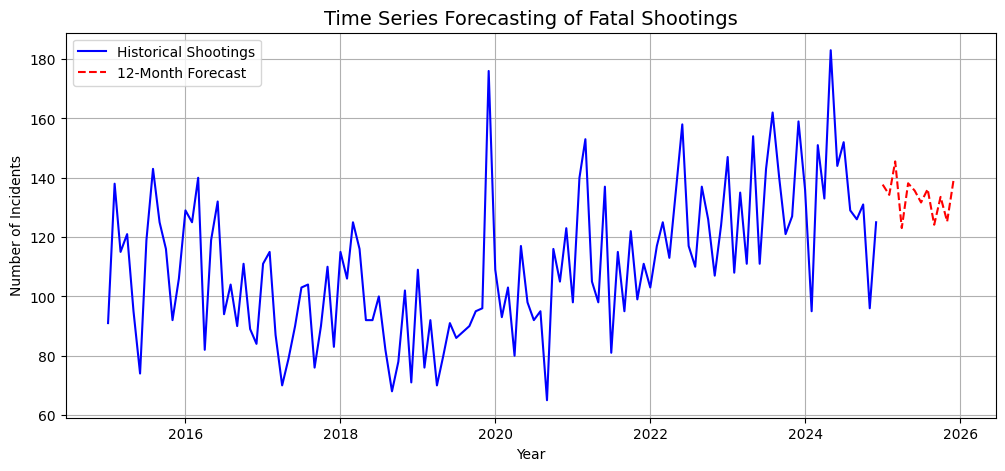

In [ ]:
# Aggregate data by month
ts_data = df.groupby('year_month').size().to_timestamp()

# Fit Exponential Smoothing Model (Trend & Seasonality)
# Assuming a mild yearly seasonality (periods=12)
model = ExponentialSmoothing(ts_data, trend='add', seasonal='add', seasonal_periods=12).fit()

# Forecast next 12 months
forecast = model.forecast(12)

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(ts_data.index, ts_data.values, label='Historical Shootings', color='blue')
plt.plot(forecast.index, forecast.values, label='12-Month Forecast', color='red', linestyle='dashed')
plt.title("Time Series Forecasting of Fatal Shootings", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.legend()
plt.grid(True)
plt.show()

Geospatial Segmentation (Clustering)
Using K-Means clustering on the Latitude and Longitude to segment the incidents into 5 major geographic "hotspot" clusters across the USA.

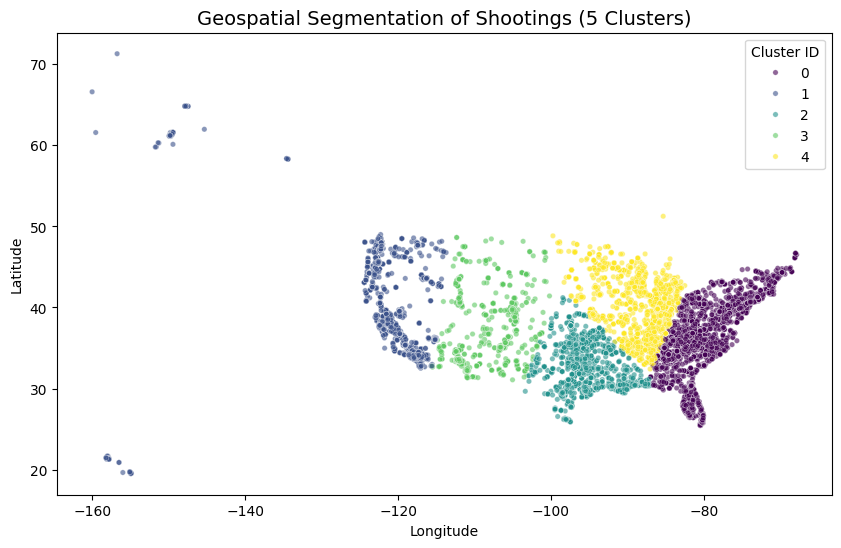

In [ ]:
# Drop rows without coordinates
geo_df = df.dropna(subset=['latitude', 'longitude']).copy()

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
geo_df['geo_cluster'] = kmeans.fit_predict(geo_df[['longitude', 'latitude']])

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='longitude', y='latitude', hue='geo_cluster', data=geo_df, palette='viridis', s=15, alpha=0.6)
plt.title("Geospatial Segmentation of Shootings (5 Clusters)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster ID")
plt.show()

Predictive Modeling (Logistic Regression)
Let's build a machine learning model to predict whether a body camera was recording based on variables like Age, Threat Type, Flee Status, and Mental Illness.

In [ ]:
# Select features and target
features = ['age', 'was_mental_illness_related', 'threat_type', 'flee_status']
target = 'body_camera'

# Drop nulls for modeling
model_df = df[features + [target]].dropna()

# Convert categorical variables to dummy variables (One-Hot Encoding)
X = pd.get_dummies(model_df[features], drop_first=True)
y = model_df[target]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = log_reg.predict(X_test)
print("--- LOGISTIC REGRESSION: PREDICTING BODY CAMERA USAGE ---")
print(classification_report(y_test, y_pred))

# Get feature importance (coefficients)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)
print("\nTop Predictors for Body Camera Usage:")
print(feature_importance.head())

--- LOGISTIC REGRESSION: PREDICTING BODY CAMERA USAGE ---
              precision    recall  f1-score   support

       False       0.87      0.58      0.69      2887
        True       0.19      0.53      0.28       530

    accuracy                           0.57      3417
   macro avg       0.53      0.55      0.49      3417
weighted avg       0.76      0.57      0.63      3417


Top Predictors for Body Camera Usage:
                    Feature  Coefficient
4          threat_type_move     1.452787
7        threat_type_threat     1.080640
2        threat_type_attack     0.925128
5         threat_type_point     0.889217
8  threat_type_undetermined     0.886744
